# Text EDA

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# Load paths from .env file
data_dir = os.getenv("DATA_DIR")
images_dir = os.getenv("IMAGES_DIR")

# Load the unified TSV file
annotations_file = os.path.join(data_dir, "annotations.tsv")

In [4]:
df = pd.read_csv(annotations_file, sep="\t")

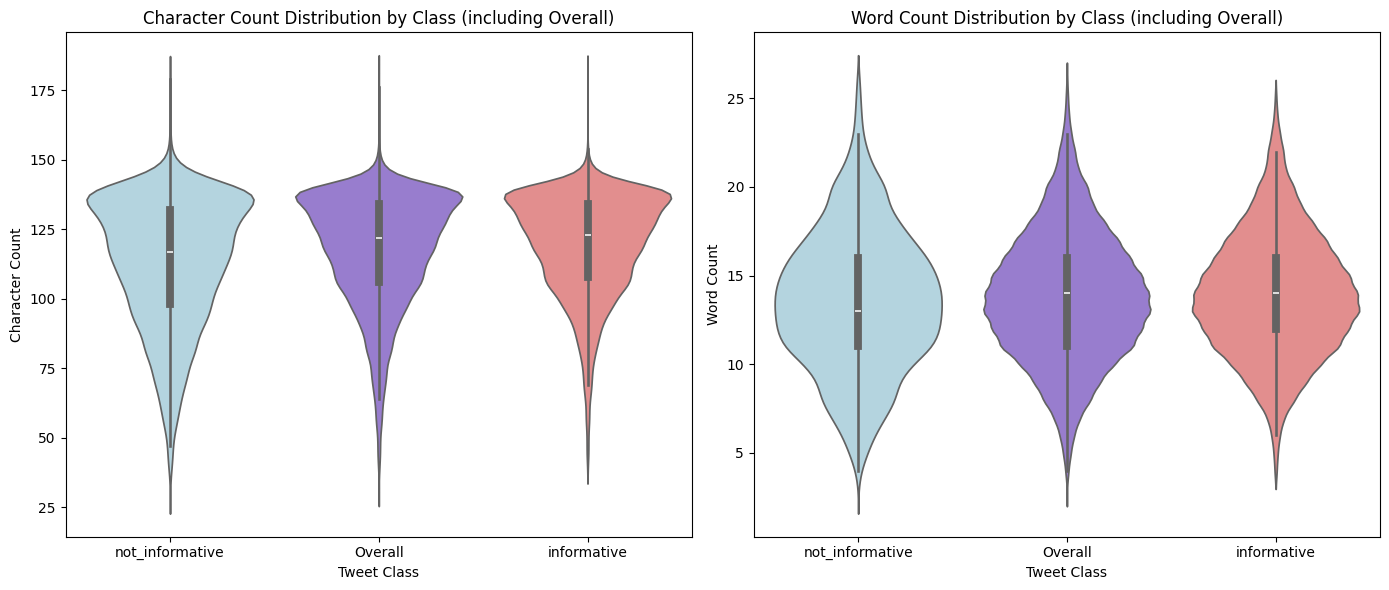

Average tweet lengths by class:
                 char_count  word_count
text_info                              
informative      119.350370   13.910152
not_informative  113.050698   13.549837

Overall averages:
   char_count  word_count
0  117.529311   13.805995


In [9]:
label_column = "text_info"

# Compute length features
df["char_count"] = df["tweet_text"].astype(str).apply(len)
df["word_count"] = df["tweet_text"].astype(str).apply(lambda x: len(x.split()))

# Create a copy for overall distribution
df_overall = df.copy()
df_overall[label_column] = "Overall"

# Combine original and overall data
df_combined = pd.concat([df, df_overall], ignore_index=True)

# Define custom order
label_order = ["not_informative", "Overall", "informative"] if "informative" in df[label_column].unique() else sorted(df[label_column].unique()) + ["Overall"]

# Plot
plt.figure(figsize=(14, 6))

# Character count violin
plt.subplot(1, 2, 1)
sns.violinplot(data=df_combined, x=label_column, y="char_count",
               order=label_order,
               palette={"not_informative": "lightblue", "informative": "lightcoral", "Overall": "mediumpurple"},
               hue=label_column,
               legend=False)
plt.title("Character Count Distribution by Class (including Overall)")
plt.xlabel("Tweet Class")
plt.ylabel("Character Count")

# Word count violin
plt.subplot(1, 2, 2)
sns.violinplot(data=df_combined, x=label_column, y="word_count",
               order=label_order,
               palette={"not_informative": "lightblue", "informative": "lightcoral", "Overall": "mediumpurple"},
               hue=label_column,
               legend=False)
plt.title("Word Count Distribution by Class (including Overall)")
plt.xlabel("Tweet Class")
plt.ylabel("Word Count")

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "tweet_length_violinplots.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

# Print averages
print("Average tweet lengths by class:")
print(df.groupby(label_column)[["char_count", "word_count"]].mean())
print("\nOverall averages:")
print(df[["char_count", "word_count"]].mean().to_frame().T)



In [10]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aceto\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


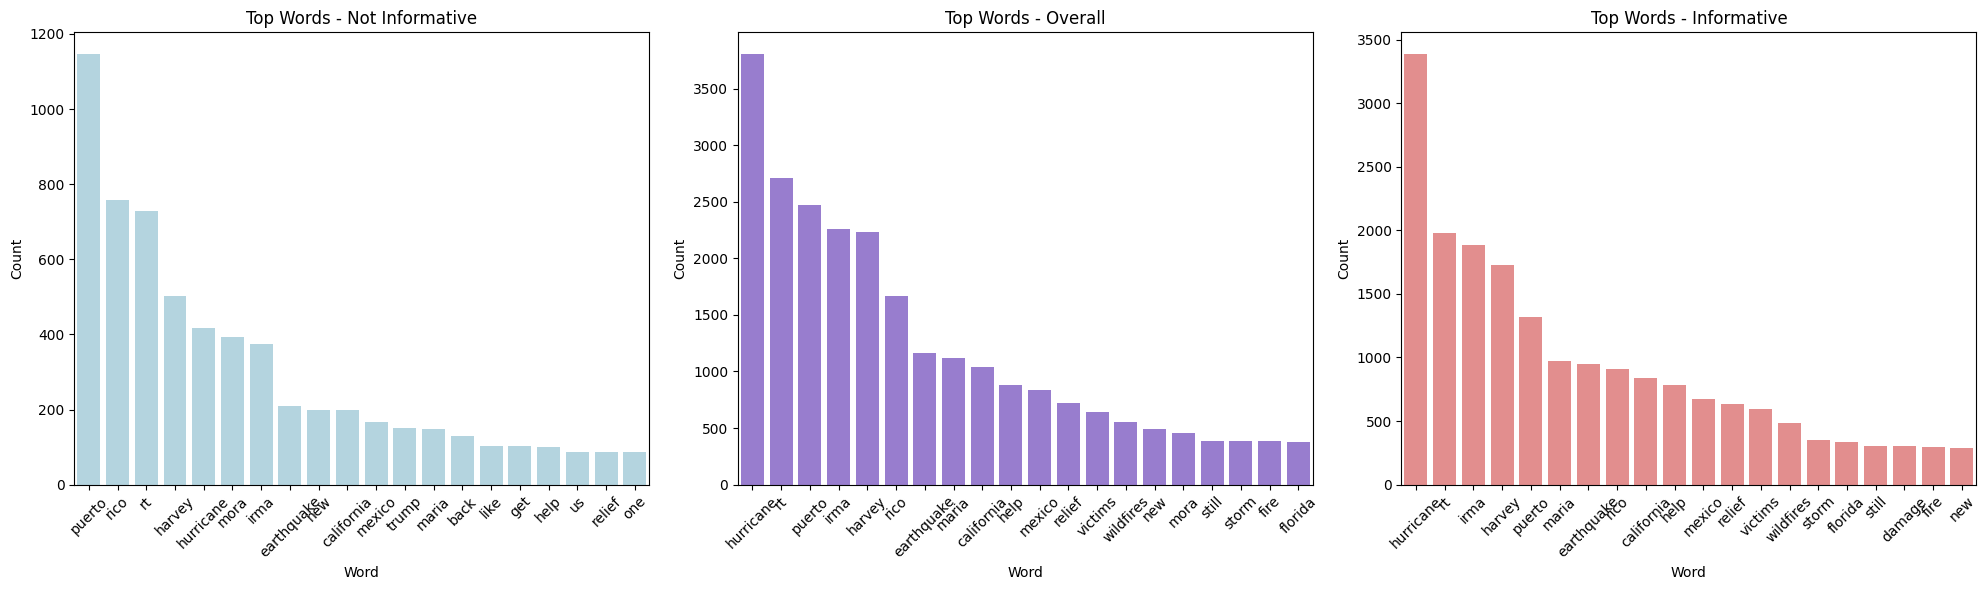

In [12]:
label_column = "text_info"
text_column = "tweet_text"

# Function to extract most frequent words
def get_top_words(texts, n=20):
    words = " ".join(texts.dropna().astype(str)).split()
    filtered = [w.lower() for w in words if w.lower() not in stop_words and w.isalpha()]
    return Counter(filtered).most_common(n)

# Extract top words
top_words_informative = get_top_words(df[df[label_column] == "informative"][text_column])
top_words_not_informative = get_top_words(df[df[label_column] == "not_informative"][text_column])
top_words_overall = get_top_words(df[text_column])

# Convert to DataFrames
df_informative = pd.DataFrame(top_words_informative, columns=["word", "count"])
df_not_informative = pd.DataFrame(top_words_not_informative, columns=["word", "count"])
df_overall = pd.DataFrame(top_words_overall, columns=["word", "count"])

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

# Not Informative
sns.barplot(data=df_not_informative, x="word", y="count", ax=axes[0], color="lightblue")
axes[0].set_title("Top Words - Not Informative")
axes[0].set_xlabel("Word")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Overall
sns.barplot(data=df_overall, x="word", y="count", ax=axes[1], color="mediumpurple")
axes[1].set_title("Top Words - Overall")
axes[1].set_xlabel("Word")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

# Informative
sns.barplot(data=df_informative, x="word", y="count", ax=axes[2], color="lightcoral")
axes[2].set_title("Top Words - Informative")
axes[2].set_xlabel("Word")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis='x', rotation=45)

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "top_words_barplots.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()
